In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

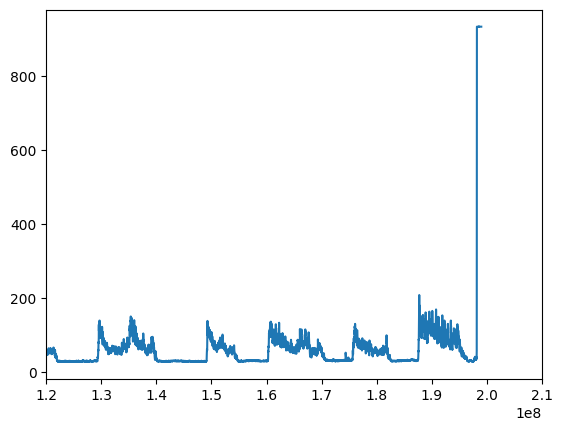

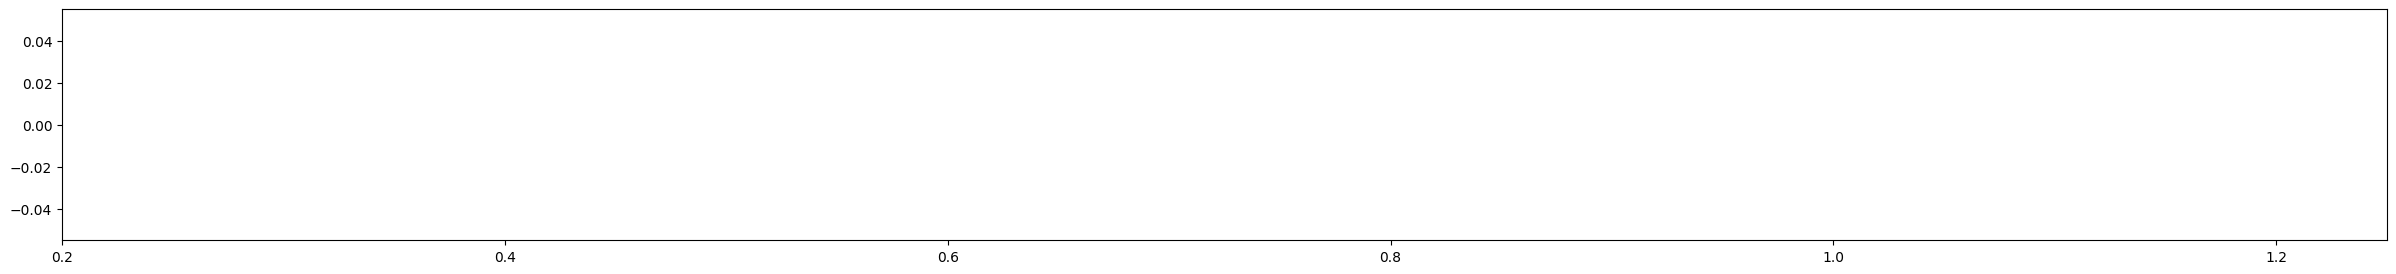

In [18]:
### Load Data
data = np.genfromtxt("C:\\Users\\temps\\PycharmProjects\\GiveAHand2026\\lk_pressed_sidepos.csv", delimiter=',')
Y = data[:,0]
X = data[:, 1]



plt.plot(X, Y)

### Normalize Data
Y = np.reshape(Y, (len(Y), 1))   # Need to reshape it to scale
scaler = StandardScaler()
scaler.fit(Y)
Y = scaler.transform(Y)

plt.xlim(1.2e8, 2.1e8)

### Clean up data
running_list = []
running_list_y = []
final_x = []
final_y = []
prev = 0
total = 0
for x, y in zip(X, Y):
    # if the times are the same, then we append the vals to a running list
    if x == prev:
        running_list.append(x)
        running_list_y.append(y[0])

    # if the times are different, then we can break up the 
    # millisecond based on how many sensor readings we got
    else:
        for index, i in enumerate(running_list):
            final_x.append(min(running_list) + (index + 1) / len(running_list))
            final_y.append(running_list_y[index])
        running_list = []
        running_list_y = []
    prev = x

### Plot Data
plt.figure(figsize=(30, 3))
plt.plot(final_x, final_y)
plt.xlim(0.2, 1.25)
plt.show()
